<a href="https://colab.research.google.com/github/ypg1um-arch/SAU_ML_TASKS/blob/main/Task_567.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import networkx as nx
import numpy as np

#Create a 10x10 NumPy adjacency matrix manually (10 nodes)
adj_matrix = np.zeros((10, 10), dtype=int)

#Define 15 manual edges to populate the matrix
edges = [
    (0, 1), (0, 2), (0, 3), (1, 2), (1, 4),
    (2, 5), (3, 4), (3, 6), (4, 7), (5, 6),
    (5, 8), (6, 9), (7, 8), (7, 9), (8, 9)
]

#Populate symmetric entries for an undirected social network
for u, v in edges:
    adj_matrix[u, v] = 1
    adj_matrix[v, u] = 1

#Create the NetworkX graph directly from the NumPy matrix
G = nx.from_numpy_array(adj_matrix)

#Confirm they encode the exact same information
#Extract the graph layout back into a matrix format
nx_matrix = nx.to_numpy_array(G, dtype=int)

#Perform element-wise comparison
is_identical = np.array_equal(adj_matrix, nx_matrix)

print(f"Matrices match exactly: {is_identical}")
print(f"NetworkX Verified Properties: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges")


Matrices match exactly: True
NetworkX Verified Properties: 10 Nodes, 15 Edges


In [2]:
import collections
import numpy as np


def get_node_degree(matrix, node):
    """Returns the total number of connections for a given node."""
    #Summing the row gives the count of all '1' links
    return int(np.sum(matrix[node]))


def get_node_neighbors(matrix, node):
    """Returns a list of all node indices connected to the target node."""
    #Find indices where the row value equals 1
    return list(np.where(matrix[node] == 1)[0])


def is_connected_bfs(matrix, start_node, end_node):
    """Checks if a path exists between start_node and end_node using BFS."""
    if start_node == end_node:
        return True

    num_nodes = matrix.shape[0]
    visited = [False] * num_nodes
    queue = collections.deque([start_node])
    visited[start_node] = True

    while queue:
        current = queue.popleft()

        #Check all neighbors of the current node[we add all the nodes visited in a queue]
        for neighbor in range(num_nodes):
            if matrix[current, neighbor] == 1 and not visited[neighbor]:
                if neighbor == end_node:
                    return True
                visited[neighbor] = True
                queue.append(neighbor)

    return False


#Verification with the previous 10x10 Matrix
#Recreating the matrix from the previous step
adj_matrix = np.zeros((10, 10), dtype=int)
edges = [
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 2),
    (1, 4),
    (2, 5),
    (3, 4),
    (3, 6),
    (4, 7),
    (5, 6),
    (5, 8),
    (6, 9),
    (7, 8),
    (7, 9),
    (8, 9),
]
for u, v in edges:
    adj_matrix[u, v], adj_matrix[v, u] = 1, 1

#Testing the custom functions
print(f"Degree of Node 0: {get_node_degree(adj_matrix, 0)}")
print(f"Neighbors of Node 0: {get_node_neighbors(adj_matrix, 0)}")
print(f"Are Node 0 and Node 9 connected? {is_connected_bfs(adj_matrix, 0, 9)}")


Degree of Node 0: 3
Neighbors of Node 0: [np.int64(1), np.int64(2), np.int64(3)]
Are Node 0 and Node 9 connected? True


In [3]:
import collections
import networkx as nx
import numpy as np

#Recreate the 10x10 Matrix and NetworkX Graph
adj_matrix = np.zeros((10, 10), dtype=int)
edges = [
    (0, 1), (0, 2), (0, 3), (1, 2), (1, 4),
    (2, 5), (3, 4), (3, 6), (4, 7), (5, 6),
    (5, 8), (6, 9), (7, 8), (7, 9), (8, 9)
]
for u, v in edges:
    adj_matrix[u, v], adj_matrix[v, u] = 1, 1

G = nx.from_numpy_array(adj_matrix)


#Custom Scratch Functions
def get_node_degree(matrix, node):
    return int(np.sum(matrix[node]))

def get_node_neighbors(matrix, node):
    return list(np.where(matrix[node] == 1)[0])

def is_connected_bfs(matrix, start_node, end_node):
    if start_node == end_node: return True
    num_nodes = matrix.shape[0]
    visited = [False] * num_nodes
    queue = collections.deque([start_node])
    visited[start_node] = True

    while queue:
        current = queue.popleft()
        for neighbor in range(num_nodes):
            if matrix[current, neighbor] == 1 and not visited[neighbor]:
                if neighbor == end_node: return True
                visited[neighbor] = True
                queue.append(neighbor)
    return False


#Run Comparative Tests
test_node = 3
target_node = 9

#Test Node Degree
scratch_degree = get_node_degree(adj_matrix, test_node)
nx_degree = G.degree(test_node)

#Test Node Neighbors
scratch_neighbors = get_node_neighbors(adj_matrix, test_node)
nx_neighbors = list(G.neighbors(test_node))

#Test Connectivity (BFS)
scratch_connected = is_connected_bfs(adj_matrix, test_node, target_node)
nx_connected = nx.has_path(G, test_node, target_node)


#Print Results Verification
print("VERIFICATION RESULTS:")
print(f"Node {test_node} Degree    -> Scratch: {scratch_degree} | NetworkX: {nx_degree} | MATCH: {scratch_degree == nx_degree}")
print(f"Node {test_node} Neighbors -> Scratch: {scratch_neighbors} | NetworkX: {nx_neighbors} | MATCH: {scratch_neighbors == nx_neighbors}")
print(f"Path {test_node} to {target_node}   -> Scratch: {scratch_connected} | NetworkX: {nx_connected} | MATCH: {scratch_connected == nx_connected}")


VERIFICATION RESULTS:
Node 3 Degree    -> Scratch: 3 | NetworkX: 3 | MATCH: True
Node 3 Neighbors -> Scratch: [np.int64(0), np.int64(4), np.int64(6)] | NetworkX: [0, 4, 6] | MATCH: True
Path 3 to 9   -> Scratch: True | NetworkX: True | MATCH: True


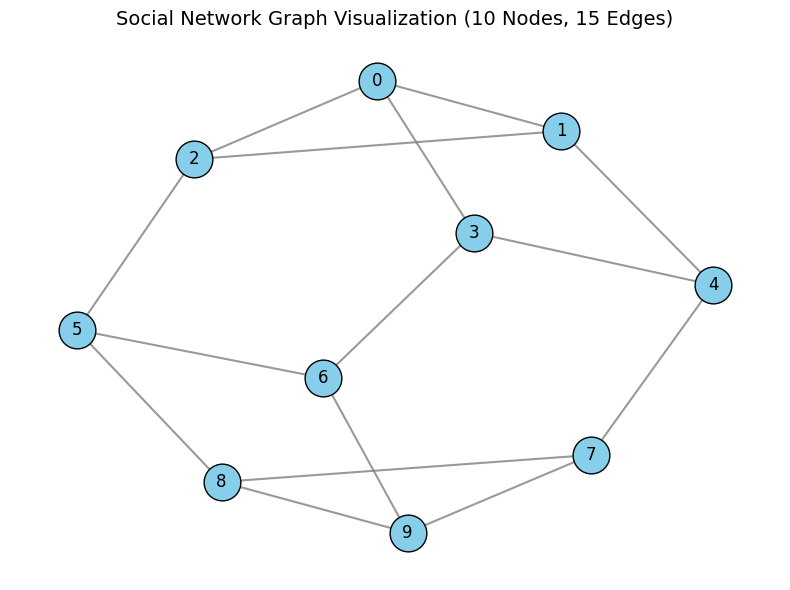

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

#Recreate the 10x10 Matrix and NetworkX Graph
adj_matrix = np.zeros((10, 10), dtype=int)
edges = [
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 2),
    (1, 4),
    (2, 5),
    (3, 4),
    (3, 6),
    (4, 7),
    (5, 6),
    (5, 8),
    (6, 9),
    (7, 8),
    (7, 9),
    (8, 9),
]
for u, v in edges:
    adj_matrix[u, v], adj_matrix[v, u] = 1, 1

G = nx.from_numpy_array(adj_matrix)

#Configure the layout and styling
plt.figure(figsize=(8, 6))

#Use spring_layout to space out the 10 nodes cleanly
pos = nx.spring_layout(G, seed=42)

#Draw the complete network components
nx.draw_networkx_nodes(
    G, pos, node_size=700, node_color="skyblue", edgecolors="black"
)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.8, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

#Final layout cleanups
plt.title("Social Network Graph Visualization (10 Nodes, 15 Edges)", fontsize=14)
plt.axis("off")  #Hide the default coordinate grid axes
plt.tight_layout()
plt.show()
